# 1. Importación de librerías

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import seaborn as sns

# 2. Carga del dataset

In [14]:
df_full = pd.read_csv('../data/processed/coffee_data_cleaned_final.csv')

# 3. Análisis de Codo y Silueta para la Especie Arabica

Análisis para especie: ARABICA
Muestras de Arabica: 1304
Muestras de Robusta reservadas: 28


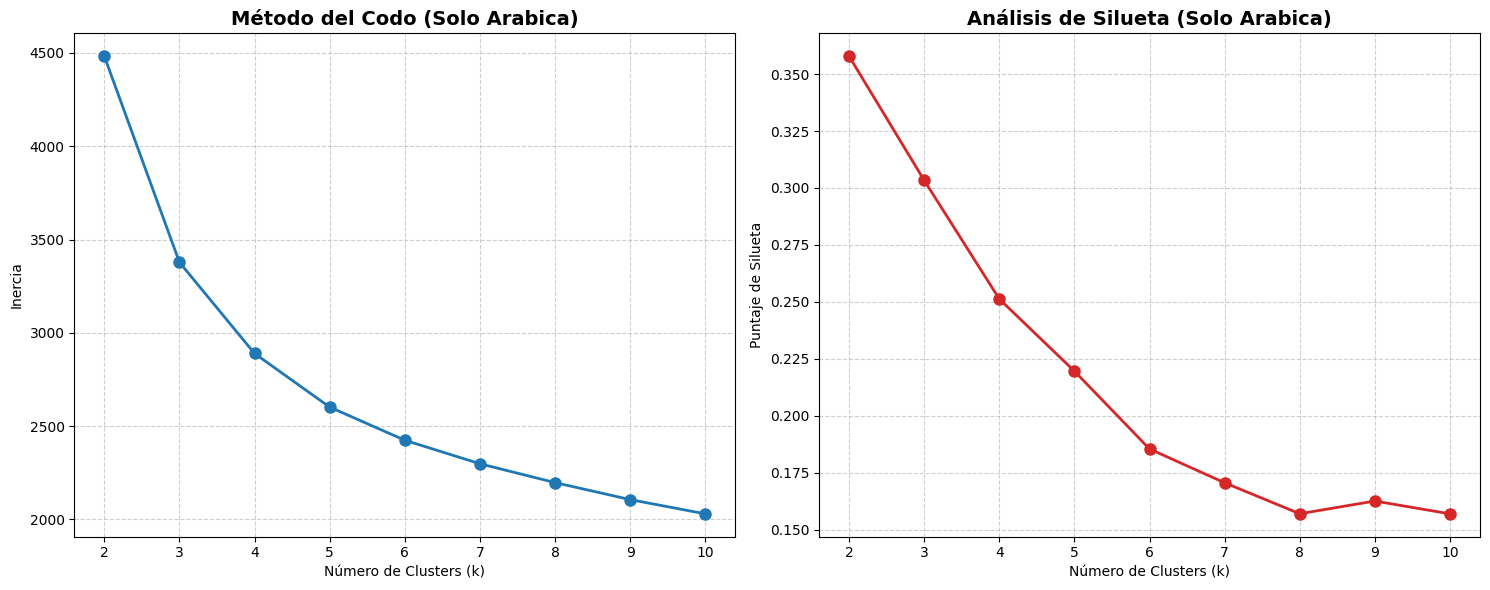

In [15]:
try:
    # 1. SEPARACIÓN ESTRATÉGICA
    # Filtramos solo Arabica para el análisis de clusters
    df = df_full[df_full['Species'] == 'Arabica'].copy()
    robusta_count = len(df_full[df_full['Species'] == 'Robusta'])
    
    print(f"Análisis para especie: ARABICA")
    print(f"Muestras de Arabica: {df.shape[0]}")
    print(f"Muestras de Robusta reservadas: {robusta_count}")

    # 2. Selección de columnas sensoriales
    features_sabor = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']
    X = df[features_sabor]

    # 3. Escalado de datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 4. Cálculo de métricas para k de 2 a 10
    inercia = []
    siluetas = []
    rango_k = range(2, 11)

    for k in rango_k:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        
        inercia.append(kmeans.inertia_)
        siluetas.append(silhouette_score(X_scaled, labels))

    # 5. Generación de las gráficas
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Gráfica del Codo
    ax1.plot(rango_k, inercia, 'o-', color='#1f77b4', linewidth=2, markersize=8)
    ax1.set_title('Método del Codo (Solo Arabica)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Número de Clusters (k)')
    ax1.set_ylabel('Inercia')
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Gráfica de Silueta (Se eliminó la anotación del máximo)
    ax2.plot(rango_k, siluetas, 'o-', color='#d62728', linewidth=2, markersize=8)
    ax2.set_title('Análisis de Silueta (Solo Arabica)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Número de Clusters (k)')
    ax2.set_ylabel('Puntaje de Silueta')
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Error: {e}")

# 4.Aplicación de K-Means (k=3) en Arabica y Categorización de Robusta

In [16]:
# 1. Preparar datos finales (Solo Arabica)
df_arabica = df_full[df_full['Species'] == 'Arabica'].copy()
df_robusta = df_full[df_full['Species'] == 'Robusta'].copy()
features_sabor = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']
scaler = StandardScaler()
X_arabica_scaled = scaler.fit_transform(df_arabica[features_sabor])

# 2. Entrenar K-Means con k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_arabica['Cluster'] = kmeans.fit_predict(X_arabica_scaled)

# 3. Asignar a Robusta un cluster único (ej. el número 3)
df_robusta['Cluster'] = 3

# 4. Unir todo el dataset de nuevo
df_final = pd.concat([df_arabica, df_robusta]).reset_index(drop=True)

# 5. Ver el "ADN" de cada grupo
resumen = df_final.groupby('Cluster')[features_sabor].mean()
print(resumen)

# Contar cuántos cafés hay en cada uno
print("\n📦 Cantidad de cafés por grupo:")
print(df_final['Cluster'].value_counts().sort_index())

            Aroma    Flavor  Aftertaste   Acidity      Body   Balance
Cluster                                                              
0        7.883725  7.894771    7.785131  7.895588  7.830327  7.893954
1        7.576199  7.543660    7.421872  7.528851  7.516553  7.540270
2        7.230410  7.091945    6.962901  7.192628  7.222389  7.097884
3        7.702500  7.630714    7.559643  7.657143  7.506786  7.541786

📦 Cantidad de cafés por grupo:
Cluster
0    306
1    705
2    293
3     28
Name: count, dtype: int64


# 5.Mapa Bidimensional de Perfiles Sensoriales (Arabica)

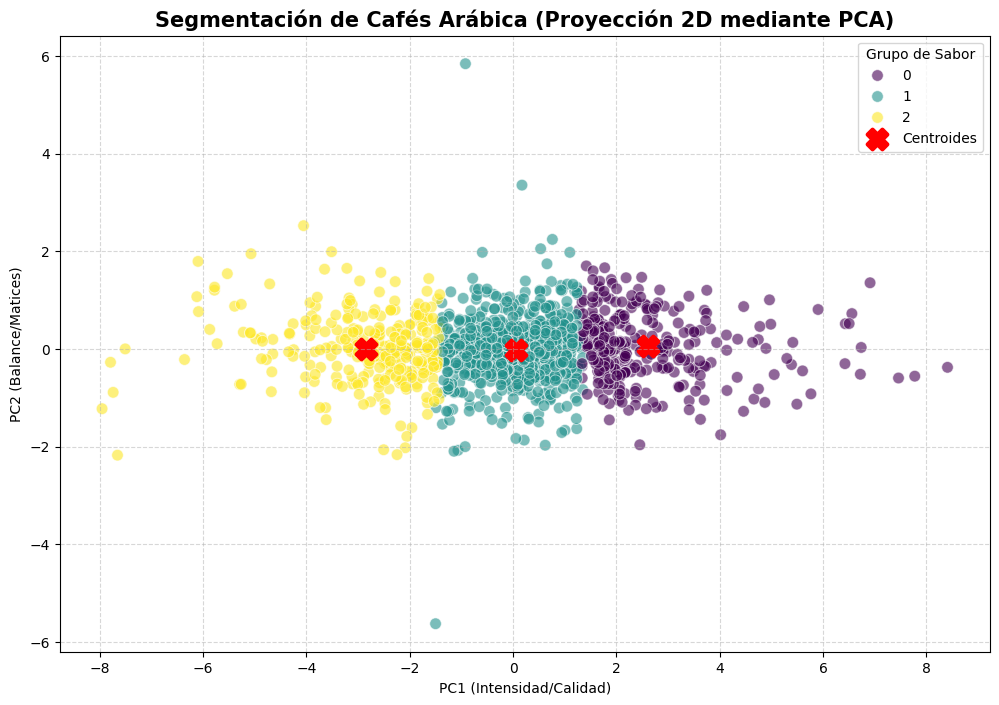

📊 El gráfico explica el 81.81% de la varianza total de los datos.


In [17]:
# Filtramos solo Arabica
df_arabica = df_full[df_full['Species'] == 'Arabica'].copy()
features_sabor = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_arabica[features_sabor])

# Aplicamos K-Means con k=3 (según lo decidido)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_arabica['Cluster'] = kmeans.fit_predict(X_scaled)

# --- REDUCCIÓN DE DIMENSIONES (PCA) ---
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Creamos un DataFrame temporal para el gráfico
df_plot = pd.DataFrame(
    data=pca_data, 
    columns=['PC1 (Intensidad/Calidad)', 'PC2 (Balance/Matices)']
)
df_plot['Cluster'] = df_arabica['Cluster'].values

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='PC1 (Intensidad/Calidad)', 
    y='PC2 (Balance/Matices)', 
    hue='Cluster', 
    data=df_plot, 
    palette='viridis', 
    s=70, 
    alpha=0.6,
    edgecolor='w'
)

# Añadir los centroides (puntos medios de cada cluster) en el espacio PCA
centroids_scaled = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids_scaled)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1], 
    marker='X', s=200, linewidths=3, color='red', label='Centroides'
)

plt.title('Segmentación de Cafés Arábica (Proyección 2D mediante PCA)', fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Grupo de Sabor')
plt.show()

# Explicación de la varianza
print(f"📊 El gráfico explica el {pca.explained_variance_ratio_.sum()*100:.2f}% de la varianza total de los datos.")